In [1]:
include("MiniCollectiveSpins.jl")
using PyPlot
using Statistics
using JLD2
using ProgressBars

### Define the system

In [2]:
# Parameters
N = 10
sat = vcat([0.1:0.1:0.9;], [1:35;])
sat_computed = sat
pathname_density_distrib = "Groundstate_Bext_90_deg_as_98.h5"
@load "Density_distributions\\$(pathname_density_distrib[1:end-3])_N_$(N).jld2" CS_densities_cuts_norm
n_list = CS_densities_cuts_norm[1:10:length(CS_densities_cuts_norm)]  # List of densities to simulate.

# Quantization axis along z
e = [0, 0, 1.]

# Constants
λ = 421e-9
γ = 32.7e6 # In Hz
@load "op_list/op_list_$N.jdl2" op_list;

In [3]:
println("Nbr of Atoms simulated = $(length(n_list)*10)")

Nbr of Atoms simulated = 8450


### Recover data from simulations

In [4]:
list_t_N, popup_t_N, sol_t_N, nbr_error_N = [], [], [], []

for (i, s) in ProgressBar(enumerate(sat_computed))
    line = []
    @load "solutions/Sat_$(minimum(sat))to$(maximum(sat))_n0_$(round(mean(n_list), digits=2))/sol_N_$(N)_Sat_$(sat[i])_stripe_distribution_$(pathname_density_distrib[1:end-3])_n0_$(round(mean(n_list), digits=2)).jld2" N n_list sat sol_tasks
    list_t, popup_t, sol_t =  [vcat([st[i] for st in sol_tasks]...) for i = 1:3]
    push!(list_t_N, list_t), push!(popup_t_N, popup_t), push!(sol_t_N, sol_t), push!(nbr_error_N, sum(vcat([st[4] for st in sol_tasks]...)))
end


0.0%┣                                               ┫ 0/44 [00:01<-1:00, -1s/it]
2.3%┣█                                          ┫ 1/44 [00:03<Inf:Inf, InfGs/it]
6.8%┣███▎                                            ┫ 3/44 [00:03<00:56, 1s/it]
15.9%┣███████▌                                       ┫ 7/44 [00:03<00:17, 2it/s]
22.7%┣██████████▌                                   ┫ 10/44 [00:03<00:11, 3it/s]
31.8%┣██████████████▋                               ┫ 14/44 [00:03<00:07, 4it/s]
34.1%┣███████████████▊                              ┫ 15/44 [00:03<00:06, 5it/s]
43.2%┣███████████████████▉                          ┫ 19/44 [00:03<00:04, 6it/s]
52.3%┣████████████████████████                      ┫ 23/44 [00:03<00:03, 7it/s]
54.5%┣█████████████████████████                     ┫ 24/44 [00:03<00:03, 7it/s]
61.4%┣████████████████████████████▎                 ┫ 27/44 [00:03<00:02, 8it/s]
70.5%┣████████████████████████████████▍             ┫ 31/44 [00:03<00:01, 9it/s]
79.5%┣██████████████████████

# Plots of the time evolution

0.0%┣                                               ┫ 0/44 [00:00<00:00, -0s/it]
2.3%┣█                                          ┫ 1/44 [00:01<Inf:Inf, InfGs/it]
4.5%┣██▏                                             ┫ 2/44 [00:01<00:38, 1it/s]
6.8%┣███▎                                            ┫ 3/44 [00:01<00:25, 2it/s]
9.1%┣████▍                                           ┫ 4/44 [00:01<00:20, 2it/s]
11.4%┣█████▍                                         ┫ 5/44 [00:02<00:17, 2it/s]
13.6%┣██████▍                                        ┫ 6/44 [00:02<00:16, 2it/s]
15.9%┣███████▌                                       ┫ 7/44 [00:02<00:14, 3it/s]
18.2%┣████████▌                                      ┫ 8/44 [00:03<00:14, 3it/s]
20.5%┣█████████▋                                     ┫ 9/44 [00:03<00:14, 3it/s]
22.7%┣██████████▌                                   ┫ 10/44 [00:03<00:13, 3it/s]
25.0%┣███████████▌                                  ┫ 11/44 [00:04<00:12, 3it/s]
27.3%┣████████████▌         

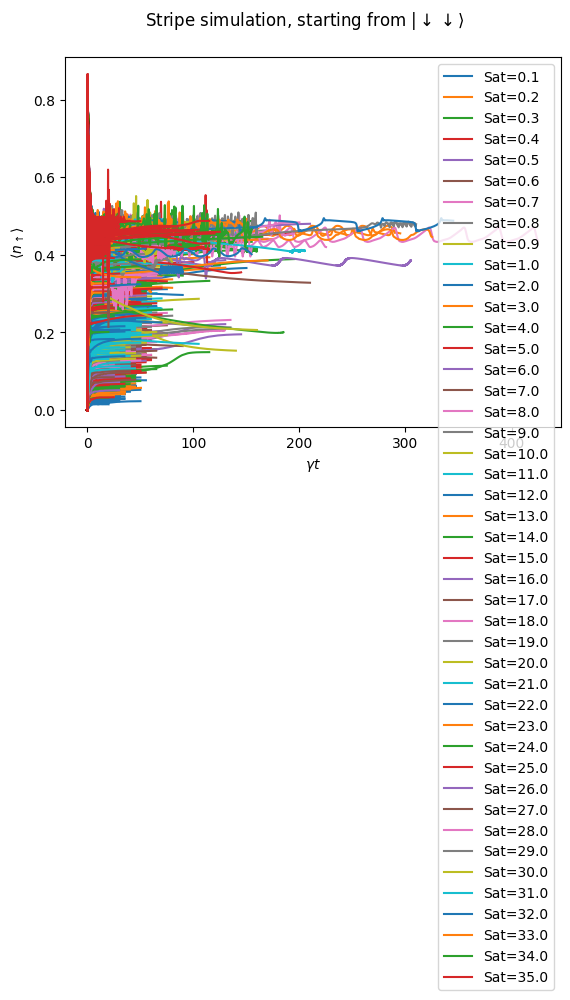

<sys>:0: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.


In [5]:
close("all")
fig, ax = subplots()

for (i, s) in ProgressBar(enumerate(sat_computed))
    line = []
    for j in 1:length(popup_t_N[i])
        if line == []
            line, = ax.plot(list_t_N[i][j], popup_t_N[i][j] / N, label="Sat=$(s)")
        else
            ax.plot(list_t_N[i][j], popup_t_N[i][j] / N, color=line.get_color()) # marker="o", markersize=1,
        end
    end
end

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle  n_{\uparrow} \rangle $")
ax.legend()

suptitle("Stripe simulation, starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()

### Density dependancy

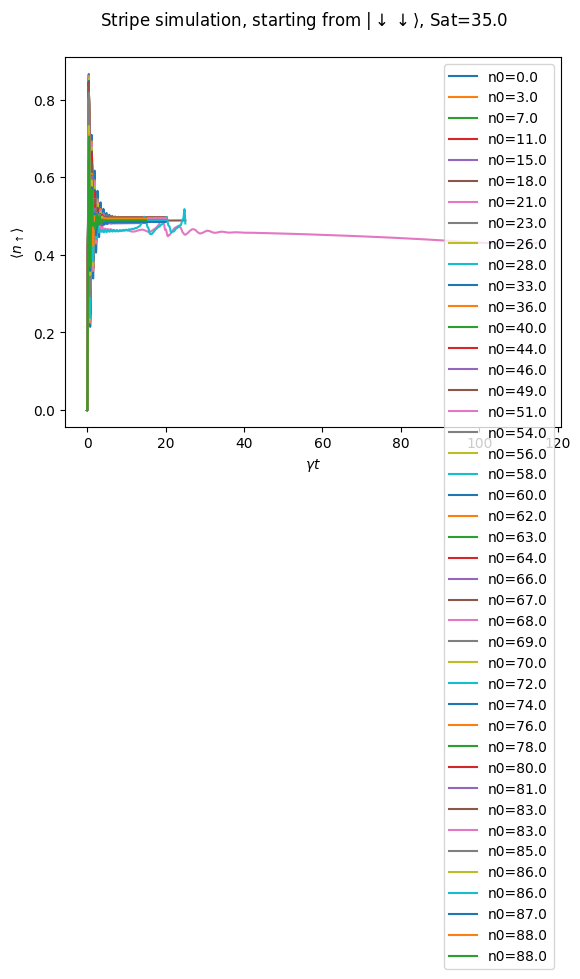

In [6]:
close("all")
fig, ax = subplots()

i = length(sat_computed) # Saturation intensity

line = []
for j in 1:20:length(popup_t_N[i])
    line, = ax.plot(list_t_N[i][j], popup_t_N[i][j] / N, label="n0=$(round(n_list[j]))")
end


ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle  n_{\uparrow} \rangle $")
ax.legend()

suptitle("Stripe simulation, starting from "*L"$|\downarrow \downarrow \rangle $"*", Sat=$(sat[i])")
pygui(false); gcf();
# pygui(true); show()

# Mean of the SS

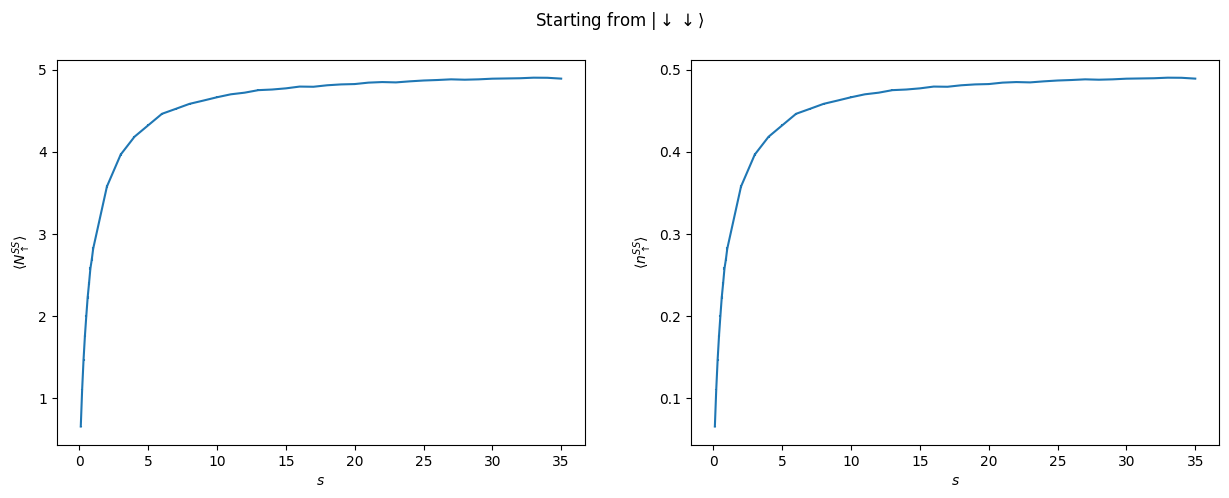

In [7]:
mean_SS = mean.([[popup_t_N[i][j][end] for j = 1:length(popup_t_N[i])] for i = 1:length(popup_t_N)])
std_SS = std.([[popup_t_N[i][j][end] for j = 1:length(popup_t_N[i])] for i = 1:length(popup_t_N)])

fig, axes = subplots(1, 2, figsize = (15, 5))
axes[1].errorbar(sat_computed, mean_SS, yerr=std_SS ./ sqrt.([length(popup_t_N[i]) for i = 1:length(sat_computed)]))
axes[1].set_xlabel(L"s")
axes[1].set_ylabel(L"$\langle  N_{\uparrow}^{SS} \rangle $")

axes[2].errorbar(sat_computed, mean_SS./N, yerr=std_SS ./ (N .* sqrt.([length(popup_t_N[i]) for i = 1:length(sat_computed)])))
axes[2].set_xlabel(L"s")
axes[2].set_ylabel(L"$\langle  n_{\uparrow}^{SS} \rangle $")

suptitle("Starting from "*L"$|\downarrow \downarrow \rangle $")

pygui(false); gcf();
# pygui(true); show()

# Compute $\gamma_{SE}$ from the SR SS

In [8]:
I_SE_SR_SS = zeros(ComplexF64, (length(sat_computed), length(n_list)))

for (i, s) in enumerate(sat_computed)
    for j in 1:length(n_list)
        
        if length(sol_t_N[i][j][end]) > 1 # If the full solution yas saved
            sol_SS = sol_t_N[i][j][end]
        else
            sol_SS = sol_t_N[i][j] # Only the SS was saved
        end

        for a = 1:N
            I_SE_SR_SS[i, j] += sol_SS[a] # The decay rates are normalized by γ
        end
    end
end
I_SE_SR_SS = real.(I_SE_SR_SS); # This is the mean decay rate of SE in the full stripe

# Compute $\gamma_{SR}$ from the SR SS

In [9]:
I_SR_SR_SS = zeros(ComplexF64, (length(sat_computed), length(n_list)))

for (i, s) in ProgressBar(enumerate(sat_computed))
    for j in 1:length(n_list)
        @load "r0/Sat_$(minimum(sat))to$(maximum(sat))_n0_$(round(mean(n_list), digits=2))/r0_N_$(N)_density_idx_$(i)_sat_$(round(sat[i], digits=1))_n0_$(round(mean(n_list), digits=2)).jdl2" r0 L

        system = SpinCollection(r0, e, gammas=1.)
        Γ_CS = GammaMatrix(system)
        
        if length(sol_t_N[i][j][end]) > 1 # If the full solution yas saved
            sol_SS = sol_t_N[i][j][end]
        else
            sol_SS = sol_t_N[i][j] # Only the SS was saved
        end

        for a = 1:N
            for b = 1:N
                if b > a # Correlated decay
                    corr = [21*10^(floor(Int, log10(a))+1)+a, 12*10^(floor(Int, log10(b))+1)+b]
                    try
                        I_SR_SR_SS[i, j] += 2*Γ_CS[a, b]*sol_SS[findall(x->x==corr || x==reverse(corr), op_list)[1]]
                    catch
                        println("Error @ $N, r=$j, a=$a, b=$b, corr=$corr")
                    end
                end
            end
        end
    end
end
I_SR_SR_SS = real.(I_SR_SR_SS); # This is the mean decay rate of SR in the full stripe

0.0%┣                                               ┫ 0/44 [00:00<00:00, -0s/it]
2.3%┣█                                          ┫ 1/44 [00:03<Inf:Inf, InfGs/it]
4.5%┣██▏                                             ┫ 2/44 [00:05<03:16, 5s/it]
6.8%┣███▎                                            ┫ 3/44 [00:06<02:09, 3s/it]
9.1%┣████▍                                           ┫ 4/44 [00:08<01:49, 3s/it]
11.4%┣█████▍                                         ┫ 5/44 [00:11<01:43, 3s/it]
13.6%┣██████▍                                        ┫ 6/44 [00:12<01:34, 2s/it]
15.9%┣███████▌                                       ┫ 7/44 [00:14<01:28, 2s/it]
18.2%┣████████▌                                      ┫ 8/44 [00:16<01:22, 2s/it]
20.5%┣█████████▋                                     ┫ 9/44 [00:18<01:17, 2s/it]
22.7%┣██████████▌                                   ┫ 10/44 [00:19<01:13, 2s/it]
25.0%┣███████████▌                                  ┫ 11/44 [00:21<01:10, 2s/it]
27.3%┣████████████▌         

In [10]:
Itot = I_SE_SR_SS .+ I_SR_SR_SS;

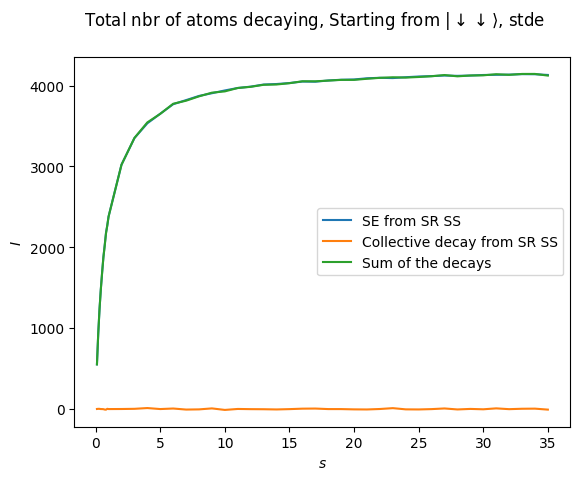

In [11]:
close("all")
fig = subplots()

plot(sat_computed, sum(I_SE_SR_SS, dims=2), label="SE from SR SS")
plot(sat_computed, sum(I_SR_SR_SS, dims=2), label="Collective decay from SR SS")
plot(sat_computed, sum(Itot, dims=2), label="Sum of the decays")

xlabel(L"s")
ylabel(L"$I$")

suptitle("Total nbr of atoms decaying, Starting from "*L"$|\downarrow \downarrow \rangle $, stde")
legend()

# pygui(true); show()
pygui(false);

# Convert to photon/$m^2$

In [ ]:
S_ellipse = π*10e-6*2e-6# 153e-12
S_ellipse *= λ^2

Itot_per_stripe = sum(Itot, dims=2) * γ
I_SE_SR_SS_per_stripe = sum(I_SE_SR_SS, dims=2) * γ
I_SR_SR_SS_per_stripe = sum(I_SR_SR_SS, dims=2) * γ

# Itot_per_stripe = Itot_per_stripe * (1 ./ mean(L_list*λ)^2)
# I_SE_SR_SS_per_stripe = I_SE_SR_SS_per_stripe * (1 ./ mean(L_list*λ)^2)
# I_SR_SR_SS_per_stripe = I_SR_SR_SS_per_stripe * (1 ./ mean(L_list*λ)^2);

# Itot_per_stripe = Itot_per_stripe / (10*length(n_list))
# I_SE_SR_SS_per_stripe = I_SE_SR_SS_per_stripe / (10*length(n_list))
# I_SR_SR_SS_per_stripe = I_SR_SR_SS_per_stripe / (10*length(n_list))

Itot_per_stripe = Itot_per_stripe * (1 ./ S_ellipse)
I_SE_SR_SS_per_stripe = I_SE_SR_SS_per_stripe * (1 ./ S_ellipse)
I_SR_SR_SS_per_stripe = I_SR_SR_SS_per_stripe * (1 ./ S_ellipse)
Itot_per_stripe

In [ ]:
S_big_cube

In [ ]:
L = sum((N ./ n_list).^(1/3)) * λ * 1e6

In [ ]:
plot(L_list .* λ * 1e6)

In [ ]:
L = sum((N ./ n_list).^(1/3)) * λ
S_big_cube = 6 * L^2

Itot_per_stripe = sum(I_SR_SR_SS, dims=2) * γ
I_SE_SR_SS_per_stripe = sum(I_SE_SR_SS, dims=2) * γ
I_SR_SR_SS_per_stripe = sum(Itot, dims=2) * γ

Itot_per_stripe = Itot_per_stripe * (1 ./ S_big_cube)
I_SE_SR_SS_per_stripe = I_SE_SR_SS_per_stripe * (1 ./ S_big_cube)
I_SR_SR_SS_per_stripe = I_SR_SR_SS_per_stripe * (1 ./ S_big_cube) # mean(L_list*λ)^2);

# Itot_per_stripe *= 10
# I_SE_SR_SS_per_stripe *= 10
# I_SR_SR_SS_per_stripe *= 10;

In [ ]:
close("all")
fig = subplots()

plot(sat_computed, I_SE_SR_SS_per_stripe, label="SE from SR SS")
plot(sat_computed, I_SR_SR_SS_per_stripe, label="Collective decay from SR SS")
plot(sat_computed, Itot_per_stripe, label="Sum of the decays")

xlabel(L"s")
ylabel(L"$I$")

suptitle("Starting from "*L"$|\downarrow \downarrow \rangle $, stde")
legend()

# pygui(true); show()
pygui(false);

In [ ]:
mean(S_list)

In [ ]:
plot(S_list)
# plot(n_list)

In [ ]:
L_list = (N ./ n_list).^(1/3)
S_list = 6*(L_list .*λ).^2;

Itot_per_stripe = Itot * γ
I_SE_SR_SS_per_stripe = I_SE_SR_SS * γ
I_SR_SR_SS_per_stripe = I_SR_SR_SS * γ

Itot_per_stripe = Itot_per_stripe * (1 ./ S_list)
I_SE_SR_SS_per_stripe = I_SE_SR_SS_per_stripe * (1 ./ S_list)
I_SR_SR_SS_per_stripe = I_SR_SR_SS_per_stripe * (1 ./ S_list);

In [ ]:
# close("all")
fig = subplots()

plot(sat_computed, I_SE_SR_SS_per_stripe, label="SE from SR SS")
plot(sat_computed, I_SR_SR_SS_per_stripe, label="Collective decay from SR SS")
plot(sat_computed, Itot_per_stripe, label="Sum of the decays")

xlabel(L"s")
ylabel(L"$I$")

suptitle("Starting from "*L"$|\downarrow \downarrow \rangle $, stde")
legend()

# pygui(true); show()
pygui(false);

In [ ]:
# Surface of the entire image
x_crop = [1300:1700;]
y_crop = [1750:2150;]
size_pxl = 0.1966e-6; # New pxl size since 2025/12/31

In [ ]:
S_img = length(x_crop)*length(y_crop)*size_pxl^2

In [ ]:
Itot_per_stripe = sum(Itot, dims=2) * γ
I_SE_SR_SS_per_stripe = sum(I_SE_SR_SS, dims=2) * γ
I_SR_SR_SS_per_stripe = sum(I_SR_SR_SS, dims=2) * γ

Itot_per_stripe = Itot_per_stripe * (1 ./ S_img)
I_SE_SR_SS_per_stripe = I_SE_SR_SS_per_stripe * (1 ./ S_img)
I_SR_SR_SS_per_stripe = I_SR_SR_SS_per_stripe * (1 ./ S_img);

In [ ]:
# close("all")
fig = subplots()

plot(sat_computed, I_SE_SR_SS_per_stripe, label="SE from SR SS")
plot(sat_computed, I_SR_SR_SS_per_stripe, label="Collective decay from SR SS")
plot(sat_computed, Itot_per_stripe, label="Sum of the decays")

xlabel(L"s")
ylabel(L"$I$")

suptitle("Starting from "*L"$|\downarrow \downarrow \rangle $, stde")
legend()

# pygui(true); show()
pygui(false);

In [ ]:
if !isdir("Itot")
    mkdir("Itot")
end
@save "Itot/Itot_N_$(N)_Sat_$(minimum(sat))to$(maximum(sat))_n0_$(round(mean(n_list), digits=2))_decay_rate_up_down.jdl2" sat sat_computed n_list Itot_per_stripe I_SE_SR_SS_per_stripe I_SR_SR_SS_per_stripe nbr_error_N